# <center> Обучение с учителем. Классификация. Практика

## <center> Прогнозирование оттока клиентов банка

## Постановка задачи

Теперь настало время самостоятельной работы. В рамках самостоятельной работы вам предстоит решить задачу прогнозирования оттока клиентов банка. 

> **Примечание.** Вы уже знакомились с этой задачей в модуле по визуализации («PYTHON-13. Визуализация данных») и провели небольшое исследование данных. Вы можете использовать результаты своего исследования для построения модели машинного обучения.

Напомним контекст задачи:

> Некоторый банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдёт ли клиент в ближайшее время. 

Итак, ранее вы провели небольшой разведывательный анализ, познакомились с данными и выявили, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов. Вы отлично справились с первой задачей, и теперь представители банка предлагают вам построить саму модель машинного обучения, которая будет прогнозировать отток клиентов. 

**Ваша задача** - построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

Разделим эту задачу на две части:
* В первой части мы подготовим данные для моделирования и построим простейшую модель логистической регрессии, оценим её качество и проанализируем результаты её работы.

* Во второй части мы займёмся построением моделей дерева решений и случайного леса, сравним их результаты с результатами, полученными на первом этапе, и сделаем финальный вывод.


Для начала импортируем библиотеки, которые нам понадобятся:

In [ ]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации
import plotly
import plotly.express as px

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import model_selection #сплитование выборки
from sklearn import preprocessing #предобработка данных
from sklearn import tree
from sklearn import ensemble
%matplotlib inline

Итак, прочитаем нашу таблицу:

In [3]:
churn_data = pd.read_csv('D:/IDE/data/churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Практика: логистическая регрессия

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9:

### Задание 5.0 (не оценивается)

Для полноты задачи проведите небольшой разведывательный анализ данных. Постройте графики распределения целевого признака, диаграммы и графики, показывающие взаимосвязь между исходными признаками и целевым признаком, а также другие диаграммы, иллюстрирующие предоставленные данные. 

**Совет:** воспользуйтесь кодом, который вы писали, выполняя задания в модуле «PYTHON-13. Визуализация данных».

In [4]:
# Ваш код здесь
churn_data1 = churn_data.copy()
churn_data1['Exited'] = churn_data1['Exited'].replace({1:'Ушедшие',0:'Лояльные'})
fig = px.box(
    data_frame=churn_data1,
    y='Balance',
    x='Exited',
    color='Exited',
    points='all',
    height=600
)

fig.show()

In [5]:
fig1 = px.box(
    data_frame=churn_data1,
    y='Age',
    x='Exited',
    color='Exited',
    points='all',
    height=600
)

fig1.show()

In [6]:
fig = px.scatter(data_frame=churn_data1,
                 x='CreditScore',
                 y='EstimatedSalary',
                 color='Exited',
                 width=1000,
                 height=800)
fig.show()

In [7]:
leaving_per = churn_data[churn_data['Exited'] == 1]

fig = px.pie(leaving_per,
             values='Exited', 
             names='Gender',
             title='Распределение ушедших клиентов по полу',
             width=500)
fig.show()

In [8]:
bar_data = churn_data1.groupby(by=['Exited','NumOfProducts'], as_index=False).count()

fig = px.bar(bar_data,
             x='Exited', 
             y='CustomerId',
             color='NumOfProducts',
             orientation='v',
             title="Распределение количества клиентов в зависимости от количества купленных продуктов банка",
             labels={'CustomerId': 'Количество клиентов','NumOfProducts': 'Количество продуктов'},
             height=600,
             width=1000)
fig.show()
display(bar_data)

,Exited,NumOfProducts,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary
0,Лояльные,1,3675,3675,3675,3675,3675,3675,3675,3675,3675,3675,3675,3675
1,Лояльные,2,4242,4242,4242,4242,4242,4242,4242,4242,4242,4242,4242,4242
2,Лояльные,3,46,46,46,46,46,46,46,46,46,46,46,46
3,Ушедшие,1,1409,1409,1409,1409,1409,1409,1409,1409,1409,1409,1409,1409
4,Ушедшие,2,348,348,348,348,348,348,348,348,348,348,348,348
5,Ушедшие,3,220,220,220,220,220,220,220,220,220,220,220,220
6,Ушедшие,4,60,60,60,60,60,60,60,60,60,60,60,60


In [9]:
churn_data1['IsActiveMember'] = churn_data1['IsActiveMember'].replace({1:'Активные', 0:'Неактивные'})

bar_data1 = churn_data1.groupby(by=['Exited','IsActiveMember'], as_index=False).count()
fig = px.bar(bar_data1,
             x='Exited', 
             y='CustomerId',
             color='IsActiveMember',
             orientation='v',
             title="Распределение количества клиентов в зависимости от статуса активного клиента ",
             labels={'CustomerId': 'Количество клиентов','IsActiveMember': 'Активный/Неактивный'},
             height=600,
             width=1000)
fig.show()


In [10]:
fig1 = px.box(
    data_frame=churn_data1,
    y='Tenure',
    x='Exited',
    color='Exited',
    points='all',
    height=600
)

fig1.show()

In [11]:

pie1_data = churn_data.groupby(by=['Exited','HasCrCard'], as_index=False).count()
pie1_data['Exited'] = pie1_data['Exited'].replace({1:'Ушедшие',0:'Лояльные'})

fig = px.bar(pie1_data,
             x='Exited', 
             y='CustomerId',
             color='HasCrCard',
             orientation='v',
             title="Распределение количества клиентов в зависимости от наличия кредитной карты",
             labels={'CustomerId': 'Количество клиентов','Exited': 'Ушедший/Лояльный'},
             height=600,
             width=1000)
fig.show()

In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
map_data = pd.DataFrame([['France', churn_data[churn_data['Geography']== 'France']['Exited'].count(), churn_data[churn_data['Geography']== 'France']['Exited'].sum()],
                         ['Spain', churn_data[churn_data['Geography']== 'Spain']['Exited'].count(), churn_data[churn_data['Geography']== 'Spain']['Exited'].sum()],
                         ['Germany', churn_data[churn_data['Geography']== 'Germany']['Exited'].count(), churn_data[churn_data['Geography']== 'Germany']['Exited'].sum()]],
                        columns=['Geography','Clients','LeavingClients'])

map_data['LeavingPercent'] = (map_data['LeavingClients'] / map_data['Clients'] * 100).round(2)

fig = px.choropleth(data_frame=map_data,
    locationmode="country names",
    locations='Geography',
    color='LeavingPercent',
    scope="europe",
    height=500,
    width=800,
    labels= {'LeavingPercent': 'Процент ушедших клиентов', 'Geography': 'Страна'},
    hover_data= ['LeavingPercent'],
    title='Проценты ушедших клиентов от числа всех клиентов в той или иной стране'
)

fig.show()


В модуле по визуализации мы выяснили, что отток в Германии, Франции и Испании имеет различные показатели. Исследователи, которые уже работали с этим датасетом, пришли к выводу, что наилучшее решение при работе с этими данными — строить модели индивидуально для каждой страны. Мы будем прогнозировать отток в немецком филиале банка. Давайте выделим только данные, относящиеся к Германии:

In [14]:
churn_data = churn_data[churn_data['Geography'] == 'Germany']
churn_data.shape

(2509, 14)

Сразу избавимся от заведомо неинформативных признаков: страна, номер строки, идентификатор пользователя и имя клиента.

In [15]:
churn_data = churn_data.drop(['Geography', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Female,29,4,115046.74,4,1,0,119346.88,1
15,616,Male,45,3,143129.41,2,0,1,64327.26,0
16,653,Male,58,1,132602.88,1,1,0,5097.67,1
26,756,Male,36,2,136815.64,1,1,1,170041.95,0
28,574,Female,43,3,141349.43,1,1,1,100187.43,0


Проверим, что в наших данных нет пропусков:

In [16]:
churn_data.isnull().sum()

CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Проверим, что в наших данных нет дубликатов:

In [17]:
churn_data[churn_data.duplicated()].sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance            0.0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    0.0
Exited               0
dtype: object

### Задание 5.1 (1 балл)

Давайте сделаем предобработку данных. 

Для начала расширим датасет с помощью методов Feature Engineering. Создайте следующие признаки:
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

Затем перекодируйте оставшиеся текстовые категориальные признаки в числовые бинарные столбцы.

Выведите основные статистические характеристики полученных признаков.

In [18]:
# Ваш код здесь
churn_data['BalanceSalaryRatio'] = churn_data['Balance'] / churn_data['EstimatedSalary']

churn_data['TenureByAge'] = churn_data['Tenure'] / churn_data['Age']

churn_data['CreditScoreGivenAge'] = churn_data['CreditScore'] / churn_data['Age']

churn_data = pd.get_dummies(churn_data, columns=['Gender'], dtype=int)

churn_data[['Gender_Female', 'Gender_Male', 'CreditScoreGivenAge', 'TenureByAge', 'BalanceSalaryRatio']].describe()

,Gender_Female,Gender_Male,CreditScoreGivenAge,TenureByAge,BalanceSalaryRatio
count,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000
mean,0.475488,0.524512,17.526487,0.134303,9.024870
std,0.499498,0.499498,5.349558,0.087680,214.286020
min,0.000000,0.000000,6.112676,0.000000,0.192582
25%,0.000000,0.000000,13.686275,0.060606,0.783284
50%,0.000000,1.000000,16.857143,0.125000,1.197220
75%,1.000000,1.000000,20.852941,0.200000,2.400083
max,1.000000,1.000000,46.388889,0.500000,10614.655440


Разделим исходный набор данных на матрицу наблюдений `X` (фичи) и столбец ответов `y` (таргет). 

In [19]:
X = churn_data.drop("Exited", axis=1)
y = churn_data["Exited"]

Прежде чем перейти к этапу разделения выборки на тренировочную и тестовую, давайте посмотрим на сбалансированность данных. Для этого воспользуемся методом `value_counts()` и выведем количество наблюдений каждого из классов в долевом соотношении от общего количества наблюдений:

In [20]:
y.value_counts(normalize=True)

Exited
0    0.675568
1    0.324432
Name: proportion, dtype: float64

Очевидно, что классы не сбалансированы. Ушедших пользователей 32 %, в то время как лояльных — 68 %.


**К чему это может привести?**

При разделении набора данных на тренировочный и тестовый может возникнуть такая ситуация, что в тренировочную выборку попадут только лояльные клиенты или их большая часть. Тогда модель может не научиться определять вероятность оттока и качество на тестовой выборке будет неудовлетворительным.

Или противоположная ситуация: в тестовую выборку попадут только лояльные клиенты. Тогда модель будет показывать отличное качество на тестовой выборке, но в реальных условиях она может оказаться бесполезной.

То есть нам нужно сделать так, чтобы в тренировочной и тестовой выборке было одинаковое соотношение лояльных и ушедших клиентов. Такое разбиение выборки называется **стратифицированным**. 

Функция `train_test_split()` из библиотеки `sklearn` умеет производить такое разбиение. Для этого в ней предусмотрен параметр `stratify`, который нужно выставить в значение признака, который должен иметь одинаковые соотношения в тренировочной и тестовой выборке. У нас этот признак - это целевой признак y. 

Выполним разбиение, установив значение параметра `random_state` на 0:


In [21]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 13)
Test shape: (628, 13)


Проверим, что число лояльных и ушедших клиентов примерно одинаково в каждой из выборок:

In [22]:
print('Train :')
display(y_train.value_counts(normalize=True))
print('\n')
print('Test :', )
display(y_test.value_counts(normalize=True))

Train :


Exited
0    0.675704
1    0.324296
Name: proportion, dtype: float64



Test :


Exited
0    0.675159
1    0.324841
Name: proportion, dtype: float64

Соотношения одинаковы, а значит, мы можем перейти к следующему шагу.

### Задание 5.2 (1 балл)

Позаботьтесь о масштабировании признаков. Проведите нормализацию/стандартизацию матрицы наблюдений `X` с помощью `MinMaxScaler`/`RobustScaler` или `StandardScaler`. Выберите метод самостоятельно.

Обучите один из предложенных скейлеров на тренировочной выборке (вычислите параметры трансформации) и примените трансформацию данных к тренировочной и тестовой выборкам.

In [23]:
# Ваш код здесь
scaler = preprocessing.MinMaxScaler()
scaler.fit(X)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Теперь переходим к моделированию.

### Задание 5.3 (1 балл)

Для начала давайте заранее определим метрику, на которую будем ориентироваться. 

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы колл-центра и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор. 


> Укажите название метрики и обоснования своего выбора здесь  

* <strong> Считаю, что основное внимание нужно оказать F1-мере, так как по условию задачи нам одинаково важно не допустить как и ложноотрицательные (FN) (клиент уйдет, хотя модель предскажет что останется), так и ложноположительные (FP) (клиент не уйдет, когда модель предскажет его уход) выводы.</strong>

> Ваши рассуждения и ответ — *здесь*.  

* <strong> Считаю, что основное внимание нужно оказать F1-мере, так как по условию задачи нам одинаково важно не допустить как и ложноотрицательные (FN) (клиент уйдет, хотя модель предскажет что останется), так и ложноположительные (FP) (клиент не уйдет, когда модель предскажет его уход) выводы.</strong>

### Задание 5.4 (2 балла)

Обучите модель логистической регрессии (`Logistic Regression`) на тренировочных данных. Позаботьтесь о воспроизводимости результата, установив конкретное значение параметра `random_state` (например, число 42).

Сделайте предсказание меток классов для тренировочной и тестовой выборок. 

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках. 

Проинтерпретируйте полученные результаты, ответив на следующий вопрос:
* Как вы считаете, является ли ваша модель переобученной или недообученной?

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

In [24]:
# Ваш код здесь
# Создаем обьект класса логистическая регрессия
log_reg = linear_model.LogisticRegression(random_state=42, penalty='l2', C=3)

# Обучаем модель
log_reg.fit(X_train_scaled, y_train)

#Делаем предсказание для тренировочной выборки
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

#Рассчитываем F1-меру
print('F1 score Train: {:.2f}'.format(metrics.f1_score(y_train_pred, y_train)))

print('F1 score Test: {:.2f}'.format(metrics.f1_score(y_test_pred, y_test)))



F1 score Train: 0.51
F1 score Test: 0.49


> Ваши выводы и рассуждения — *здесь*.  
* <strong> При отсутствии настроек типа регуляризации и коэффициента обратного коэффициенту регуляризации результат F1 меры = 0.49, что по условию является недообученной, с помощью доп.настроек можно добиться повышения показателя F1 меры до 0.51, что явно несильно отличается от показателя недообученности в 0.50 </strong>

### Задание 5.5 (2 балла)

Сгенерируйте полиномиальные признаки третьей степени для тренировочной и тестовой выборок. Используйте класс `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` выставите в значение `False`.

> **Примечание.** Обратите внимание, что для генерации полиномов необходимо использовать масштабированные данные.

Обучите модель логистической регрессии на полиномиальных признаках (`Logistic Regression`). Позаботьтесь о воспроизводимости результат, установив конкретное значение параметра `random_state` (например, число 42).

Предскажите метки классов для тренировочной и тестовой выборок.

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках для модели, обученной на полиномиальных признаках.

Сравните результат с полученным ранее. Удалось ли вам улучшить качество вашей модели?

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

In [25]:
# Ваш код здесь
#Создаем объект для генерации полиномиальных признаков степени 3
poly = preprocessing.PolynomialFeatures(degree=3, include_bias=False)
#Вычисляем параметры генерации - результирующее количество признак
poly.fit(X_train_scaled)
#Производим преобразование для каждой из выборок
X_train_scaled_poly = poly.transform(X_train_scaled)
X_test_scaled_poly = poly.transform(X_test_scaled)

# Создаем обьект класса логистическая регрессия
log_reg_poly = linear_model.LogisticRegression(random_state=42, penalty='l2', C=3)

# Обучаем модель
log_reg_poly.fit(X_train_scaled_poly, y_train)

#Делаем предсказание для тренировочной выборки
y_train_pred_poly = log_reg_poly.predict(X_train_scaled_poly)
y_test_pred_poly = log_reg_poly.predict(X_test_scaled_poly)

#Рассчитываем F1-меру
print('F1 score Train: {:.2f}'.format(metrics.f1_score(y_train_pred_poly, y_train)))

print('F1 score Test: {:.2f}'.format(metrics.f1_score(y_test_pred_poly, y_test)))

F1 score Train: 0.70
F1 score Test: 0.66


> Ваши выводы и рассуждения — *здесь*  
* <strong> С помощью использования генерации полиномиальных признаков 3 степени удалось увеличить показатель метрики f1 меры до 0.66, также с помощью l2 регуляризации и повышения коэффициента обратного коэффициенту регуляризации до 3, показатель целевой метрики вырос до 0.70</strong>

### Задание 5.6. (2 балла)


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. В качестве модели используйте логистическую регрессию, обученную на полиномиальных признаках. 

В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список.

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученными ранее.


Максимальный порог вероятности: 0.30
F1 score Train: 0.71
F1 score Test: 0.71


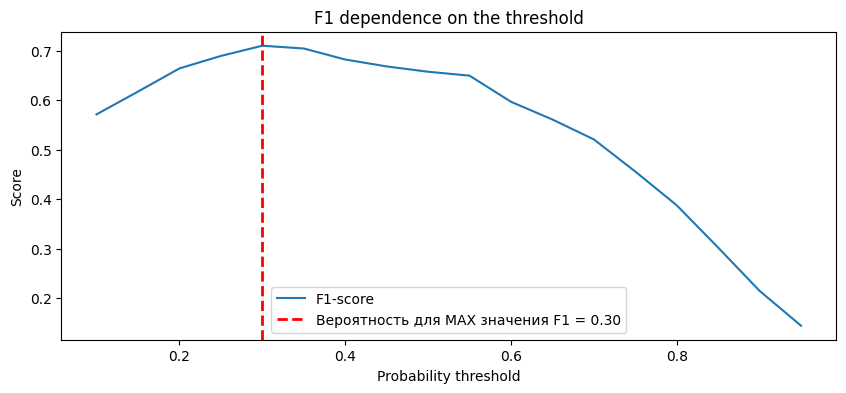

In [53]:
# Ваш код здесь
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(log_reg_poly.predict_proba(X_test_scaled_poly)[:, 1])
# Делаем предсказание вероятности оттока для каждого клиента из тренировочной выборки
y_train_proba_pred = pd.Series(log_reg_poly.predict_proba(X_train_scaled_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = metrics.f1_score(y_test, y_test_pred_poly)# код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
    
#Визуализируем метрики при различных threshold
fig, ax = plt.subplots(figsize=(10, 4)) #фигура + координатная плоскость
#Строим линейный график зависимости F1 от threshold
ax.plot(thresholds, scores, label='F1-score')
#Посторим перпендикулярную максимальному значению F1 линию для отметки порога вероятности

x_data = thresholds
y_data = scores
max_y_index = np.argmax(y_data)
x_at_ymax = x_data[max_y_index]

ax.axvline(x=x_at_ymax, color='red', linestyle='--', linewidth=2,
                label=f'Вероятность для MAX значения F1 = {x_at_ymax:.2f}')

#Даем графику название и подписи осям
ax.set_title('F1 dependence on the threshold')
ax.set_xlabel('Probability threshold')
ax.set_ylabel('Score')
ax.legend()

print(f'Максимальный порог вероятности: {x_at_ymax:.2f}')

#Задаем оптимальный порог вероятностей
threshold_opt = 0.3

y_test_pred_opt = y_test_proba_pred.apply(lambda x: 1 if x > threshold_opt else 0)
y_train_pred_opt = y_train_proba_pred.apply(lambda x: 1 if x > threshold_opt else 0)

#Рассчитываем F1-меру
print('F1 score Train: {:.2f}'.format(metrics.f1_score(y_train_pred_opt, y_train)))
print('F1 score Test: {:.2f}'.format(metrics.f1_score(y_test_pred_opt, y_test)))


## Практика: деревья решений и случайный лес

Мы продолжаем решать задачу прогнозирования оттока клиентов банка.

Ранее мы построили модель логистической регрессии, затем добавили в модель полиномиальные признаки и подобрали оптимальный порог вероятности для логистической регрессии.

> Теперь попробуем решить задачу с помощью деревьев решений и лесов.


> **Примечание №1.** Для выполнения дальнейших заданий необходимо совершить уже знакомые шаги предобработки с данными об оттоке клиентов банка, а именно:
* выделить данные, относящиеся к отделениям банка в Германии;
* избавиться от заведомо неинформативных признаков;
* расширить датасет путём добавления новых признаков;
* разделить выборку на тренировочную и тестовую со стратификацией.

> **Примечание №2.** Деревья решений — алгоритм, способный уловить нелинейные зависимости. Генерация полиномиальных признаков практически не имеет значения.
Также деревья решений не чувствительны к масштабу признаков. Масштабирование исходных данных не играет роли при построении деревьев решения.
Поэтому для решения задачи используйте обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) выборки без полиномиальных столбцов.


In [27]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 13)
Test shape: (628, 13)


### Задание 8.1. (2 балла)

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с неограниченной максимальной глубиной дерева. В качестве критерия информативности используйте энтропию Шеннона, остальные параметры оставьте по умолчанию. 

Также позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42). 

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сделайте вывод, ответив на вопрос:
* Как вы считаете, является полученная модель переобученной или недообученной? Попробуйте дать обоснование, почему так происходит.


In [46]:
# Ваш код здесь
dt = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий эффективности
    random_state=42 #генератор случайных чисел
)
#Обучаем модель по алгоритму CART
dt.fit(X_train, y_train)
#Делаем предсказание класса
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)
#Выводим отчёт о метриках
print(f'F1 мера дял тренировочной выборки {metrics.accuracy_score(y_train, y_train_pred):.2f}')
print(f'F1 мера для тестовой выборки {metrics.accuracy_score(y_test, y_test_pred):.2f}')

F1 мера дял тренировочной выборки 1.00
F1 мера для тестовой выборки 0.71


> Ваши выводы и рассуждения — *здесь*
* <strong> Так как, F1 мера для тренировочной выборки достигла максимального значения 1.0, в то время как, тестовая имеет показатель F1 меры 0.71, что значительно ниже тренировочной,  
  можем сделать вывод, что мождель является переобученной </strong>

### Задание 8.2. (1 балл)

Давайте «подстрижём» наше дерево. 

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с максимальной глубиной 8. В качестве критерия информативности используйте энтропию Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните результат с полученными ранее. Сделайте вывод.


In [47]:
# Ваш код здесь
dt = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий эффективности
    max_depth=8, #максимальная глубина дерева
    min_samples_leaf=10, #минимальное число объектов в листе
    random_state=42 #генератор случайных чисел
)
#Обучаем модель по алгоритму CART
dt.fit(X_train, y_train)
#Делаем предсказание класса
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)
#Выводим отчёт о метриках
print(f'F1 мера дял тренировочной выборки {metrics.accuracy_score(y_train, y_train_pred):.2f}')
print(f'F1 мера для тестовой выборки {metrics.accuracy_score(y_test, y_test_pred):.2f}')

F1 мера дял тренировочной выборки 0.83
F1 мера для тестовой выборки 0.79


> Ваши выводы и рассуждения — *здесь*
* <strong> После добавления дополнительных параметров в модель, F1 мера тренировочной выборки снизилась до приемлимых значений (0.83) и уже не так сильно отличается от тестовой (0.79),  
что может свидетельствовать об уменьшения переобученности модели </strong>

### Задание 8.3. (1 балл)

Давайте воспользуемся случайным лесом. 

Постройте случайный лес (`RandomForestClassifier`) из 500 деревьев с максимальной глубиной 8. Критерий информативности — энтропия Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните качество одного дерева решений с качеством случайного леса на тестовой выборке. Смогли ли вы улучшить метрику?


In [99]:
# Ваш код здесь
#Создаём объект класса RanndomForest
rf = ensemble.RandomForestClassifier(
    n_estimators=500, #число деревьев
    criterion='entropy', #критерий эффективности
    max_depth=8,#максимальная глубина дерева
    min_samples_leaf=10, #минимальное число объектов в листе
    random_state=42 #генератор случайных чисел
)
#Обучаем модель 
rf.fit(X_train, y_train)
 
#Делаем предсказание класса
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
#Выводим отчёт о метриках
print(f'F1 мера для тренировочной выборки {metrics.accuracy_score(y_train, y_train_pred):.2f}')
print(f'F1 мера для тестовой выборки {metrics.accuracy_score(y_test, y_test_pred):.2f}')

F1 мера для тренировочной выборки 0.85
F1 мера для тестовой выборки 0.79


> Ваши выводы и рассуждения — *здесь*
* <strong> По сравнению с одним деревом решений, метрики случайного леса решений практически не отличается, разница только в метриках для тренировочных выборках (0.83) и (0.85) соответсвенно.  
В то время как, тестовые в обеих моделях имеют одинаковые показатели F1 меры (0.79) </strong>

### Задание 8.4. (2 балла)

Мы на финишной прямой. 


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. **Используйте ту модель (из рассмотренных ранее), которая показала наилучшее качество на тестовой выборке.**


В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список. 


Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните полученный результат с полученными ранее. 

Напишите небольшой вывод о проделанной работе, указав в нём, какая из рассмотренных нами моделей показала наилучший результат.

> **Примечание.** Помните о том, что в реальных задачах (а мы решали задачу на реальных данных) мы практически никогда не сможем получить значения метрик, близкие к 1. Если в задаче прогнозирования оттока ваша метрика превышает хотя бы значения 0.6-0.7, вашу модель уже можно считать хорошей и можно говорить о том, что она успешно справляется с задачей.

Максимальный порог вероятности: 0.40
F1 score Train: 0.77
F1 score Test: 0.69


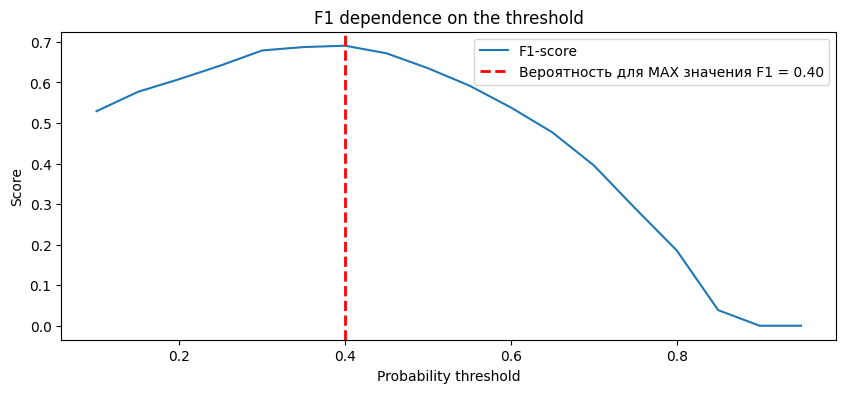

In [100]:
# Ваш код здесь
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(rf.predict_proba(X_test)[:, 1])
# Делаем предсказание вероятности оттока для каждого клиента из тренировочной выборки
y_train_proba_pred = pd.Series(rf.predict_proba(X_train)[:, 1])

# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = metrics.f1_score(y_test, y_test_pred)# код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)


#Визуализируем метрики при различных threshold
fig, ax = plt.subplots(figsize=(10, 4)) #фигура + координатная плоскость
#Строим линейный график зависимости F1 от threshold
ax.plot(thresholds, scores, label='F1-score')
#Посторим перпендикулярную максимальному значению F1 линию для отметки порога вероятности

x_data = thresholds
y_data = scores
max_y_index = np.argmax(y_data)
x_at_ymax = x_data[max_y_index]

ax.axvline(x=x_at_ymax, color='red', linestyle='--', linewidth=2,
                label=f'Вероятность для MAX значения F1 = {x_at_ymax:.2f}')

#Даем графику название и подписи осям
ax.set_title('F1 dependence on the threshold')
ax.set_xlabel('Probability threshold')
ax.set_ylabel('Score')
ax.legend()

print(f'Максимальный порог вероятности: {x_at_ymax:.2f}')    

#задаем порог вероятности
threshold_opt = 0.40

y_test_pred_opt = y_test_proba_pred.apply(lambda x: 1 if x > threshold_opt else 0)
y_train_pred_opt = y_train_proba_pred.apply(lambda x: 1 if x > threshold_opt else 0)

#Рассчитываем F1-меру
print('F1 score Train: {:.2f}'.format(metrics.f1_score(y_train_pred_opt, y_train)))
print('F1 score Test: {:.2f}'.format(metrics.f1_score(y_test_pred_opt, y_test)))



> Ваши выводы и рассуждения — *здесь*
 ## <strong> После выполнения всех работ по построению различных моделей, можно сделать вывод, что:  
## деревья решений показывают более лучшие показатели метрик, чем модели линейных регрессий (лучший результат у ансамблевой модели случайного леса).  
## Но крайне важно правильно выстраивать параметры для каждой модели и отслеживать показатели метрик.
 </strong>

### Задание 8.5. (1 балл)

Наконец, финальная задача.

У нашего банка есть некоторый клиент, назовём его Василием. В базе данных банка хранятся следующие данные о Василии:

```python
{
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
```

С помощью наилучшей модели спрогнозируйте вероятность того, что Василий откажется от услуг банка.

> **Примечание.** Учтите, что для предсказания необходимо преобразовать данные к тому формату, на котором обучалась модель, то есть:
* добавить признаки дополнительные признаки; 
* произвести кодирование категориальных признаков;
* произвести масштабирование признаков (если ваша модель обучалась на масштабированных данных) с помощью того же скейлера, который вы использовали при обучении модели;
* сгенерировать полиномиальные признаки.

In [98]:
# Ваш код здесь
df = pd.DataFrame({
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
})

df['BalanceSalaryRatio'] = df['Balance'] / df['EstimatedSalary']
df['TenureByAge'] = df['Tenure'] / df['Age']
df['CreditScoreGivenAge'] = df['CreditScore'] / df['Age']
df['Gender_Female'] = 0
df = pd.get_dummies(df, columns=['Gender'], dtype=int)

#Создаём объект класса RanndomForest
rf = ensemble.RandomForestClassifier(
    n_estimators=500, #число деревьев
    criterion='entropy', #критерий эффективности
    max_depth=8,#максимальная глубина дерева
    min_samples_leaf=10, #минимальное число объектов в листе
    random_state=42 #генератор случайных чисел
)
#Обучаем модель 
rf.fit(X_train, y_train)
 
#Делаем предсказание класса
y_pred = rf.predict(df)
print('Предсказанный класс: {}'.format(y_pred))

#Делаем предсказание вероятностей:
y_new_proba_predict = rf.predict_proba(df)
print('Предсказанная вероятность: {}'.format(np.round(y_new_proba_predict, 3)))

df['Exited'] = y_pred
df

Предсказанный класс: [1]
Предсказанная вероятность: [[0.383 0.617]]


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_Female,Gender_Male,Exited
0,601.0,42.0,1.0,98495.72,1.0,1.0,0.0,40014.76,2.461485,0.02381,14.309524,0,1,1
